# 05 - Certifying the WL level (and where the sieve breaks)

An appendix to the tour. Notebook 03 showed the sieve cover separating Rook vs
Shrikhande. Is that *beyond 3-WL*, or did the sieve just happen to look at the one
substructure that differs? Here we certify the WL level with a small oracle, then
test the sieve on a second pair built a different way but sitting at the same level.

This mirrors `run_wl.py`, with the reasoning spelled out.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # repo root, so `import src...` works
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from src.srg_data import rook44, shrikhande
from src.cfi import cfi_pair, complete_graph
from src.wl import distinguishes
from src.covers import walk_cover, reachability_cover, sieve_cover
np.set_printoptions(precision=2, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)

## The WL oracle

`src/wl.py` runs the folklore variant, k-FWL, which is equivalent to (k+1)-WL in
distinguishing power. So 2-FWL is 3-WL and 3-FWL is 4-WL. It refines colours on
tuples of vertices and compares the colour histograms of two graphs; they are
distinguished at a level iff the histograms differ. Nothing here is asserted, it is
computed.

In [2]:
R, S = rook44(), shrikhande()
for level in ["1-WL", "3-WL", "4-WL"]:
    print(f"{level:5s} distinguishes Rook/Shrikhande: {distinguishes(R, S, level)}")

1-WL  distinguishes Rook/Shrikhande: False
3-WL  distinguishes Rook/Shrikhande: False


4-WL  distinguishes Rook/Shrikhande: True


Indistinguishable at 1-WL and 3-WL, separated only at 4-WL. So this is a genuine
3-WL-indistinguishable pair, the bar the paper's claim is about, not merely a
1-WL gap.

In [3]:
def separates(fa, fb):
    a = np.sort(np.round(np.asarray(fa), 6), axis=0)
    b = np.sort(np.round(np.asarray(fb), 6), axis=0)
    return a.shape != b.shape or not np.allclose(a, b)

covers = {
    "walk":         lambda A: walk_cover(A, 4),
    "reachability": lambda A: reachability_cover(A, A.shape[0]),
    "sieve":        lambda A: sieve_cover(A),
}
for name, f in covers.items():
    print(f"{name:13s} separates Rook/Shrikhande: {separates(f(R), f(S))}")

walk          separates Rook/Shrikhande: False
reachability  separates Rook/Shrikhande: False
sieve         separates Rook/Shrikhande: True


The generic covers (walk, reachability) tie, exactly as a 2-FWL bound predicts. The
sieve cover separates the pair, by counting triangles in each node's neighbourhood:
two triangles in Rook, a single 6-cycle in Shrikhande. That is the GSN mechanism.
Is it a general beyond-3-WL separator, or specific to this substructure?

## A second pair at the same level: CFI over K4

The Cai-Fuerer-Immerman construction builds a non-isomorphic pair whose only
difference is a global parity, hidden from low-dimensional WL. Over the base graph
K4 it lands at the same WL level as Rook/Shrikhande. (The 4-WL check is O(n^4) on 28
nodes, so it takes a few seconds.)

In [4]:
A, B = cfi_pair(4, complete_graph(4))
regular = tuple(sorted(A.sum(1).astype(int))) == tuple(sorted(B.sum(1).astype(int)))
print(f"CFI(K4): {A.shape[0]} nodes, triangles tr(A^3)={int(np.trace(A @ A @ A))}, "
      f"same degree sequence={regular}")
for level in ["1-WL", "3-WL", "4-WL"]:
    print(f"{level:5s} distinguishes CFI(K4): {distinguishes(A, B, level)}")

CFI(K4): 28 nodes, triangles tr(A^3)=0, same degree sequence=True
1-WL  distinguishes CFI(K4): False
3-WL  distinguishes CFI(K4): False


4-WL  distinguishes CFI(K4): True


Same WL level: 3-WL cannot, 4-WL can. But note `tr(A^3) = 0`, so the graphs are
bipartite and contain no triangles at all, and they share a degree sequence.

In [5]:
for name, f in covers.items():
    print(f"{name:13s} separates CFI(K4): {separates(f(A), f(B))}")

walk          separates CFI(K4): False
reachability  separates CFI(K4): False
sieve         separates CFI(K4): False


The sieve cover now **fails**. With no triangles and equal degrees, every sieve
feature is identical on the two graphs. The structure that differs is global parity,
which no fixed neighbourhood substructure can see.

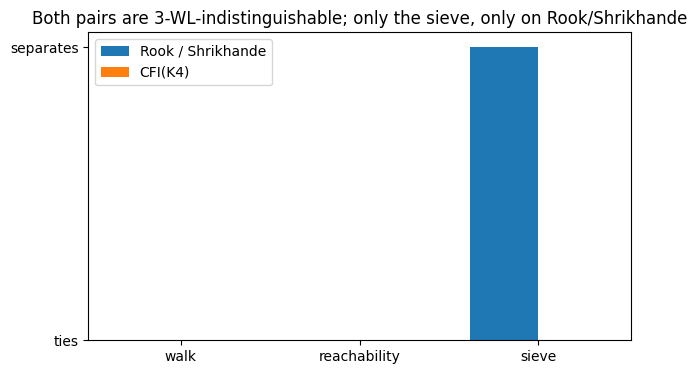

In [6]:
labels = ["walk", "reachability", "sieve"]
rs  = [int(separates(covers[k](R), covers[k](S))) for k in labels]
cfi = [int(separates(covers[k](A), covers[k](B))) for k in labels]
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots()
ax.bar(x - w/2, rs,  w, label="Rook / Shrikhande")
ax.bar(x + w/2, cfi, w, label="CFI(K4)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(["ties", "separates"])
ax.set_title("Both pairs are 3-WL-indistinguishable; only the sieve, only on Rook/Shrikhande")
ax.legend()
plt.show()

## Reading

Two pairs, identical WL level, opposite sieve verdicts. The sieve cover's reach is
exactly the substructure it was hand-given: it clears a pair only when that pair's
difference happens to be that substructure. So the beyond-3-WL win on Rook/Shrikhande
is the injected substructure (GSN), not the framework's algebra, and the generic
covers stay 2-FWL-bounded on both pairs. That is the reviewer's point, certified
rather than asserted.